# Ejercicio 6: Validación espacial

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score,
)
from xgboost import XGBClassifier

from src.config import OUT_DIR, RASTER_CRS

plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42


## 6.0 Carga de datos, variable respuesta y variables predictoras

In [2]:
df = pd.read_parquet(OUT_DIR / "ml_dataset.parquet")

UMBRAL_ALTA_CIANOBACTERIA = 10.0
df["alta_cianobacteria"] = (df["cianobacteria"] > UMBRAL_ALTA_CIANOBACTERIA).astype(int)

dia_anio = df["fecha"].dt.dayofyear
df["dia_anio_sin"] = np.sin(2 * np.pi * dia_anio / 365)
df["dia_anio_cos"] = np.cos(2 * np.pi * dia_anio / 365)
df["ndvi_x_ndwi"] = df["ndvi"] * df["ndwi"]

NUM_FEATURES = ["green", "nir", "ndvi", "ndwi", "lat", "lon",
                 "dia_anio_sin", "dia_anio_cos", "ndvi_x_ndwi"]
CAT_FEATURES = ["lago"]
FEATURES = NUM_FEATURES + CAT_FEATURES
TARGET = "alta_cianobacteria"

X = df[FEATURES].copy()
y = df[TARGET].copy()

print(f"{len(df):,} observaciones | CRS de los rasters de origen: {RASTER_CRS}")


538,675 observaciones | CRS de los rasters de origen: EPSG:32615


## 6.1 Cuadrícula espacial de 1 km × 1 km

In [3]:
BLOQUE_SIZE_M = 1000

def asignar_bloques(data, size=BLOQUE_SIZE_M):
    bloques = pd.Series(index=data.index, dtype=object)
    for lago, idx in data.groupby("lago", observed=True).groups.items():
        sub = data.loc[idx]
        col = np.floor((sub["x_utm"] - sub["x_utm"].min()) / size).astype(int)
        fila = np.floor((sub["y_utm"] - sub["y_utm"].min()) / size).astype(int)
        bloques.loc[idx] = lago + "_" + col.astype(str) + "_" + fila.astype(str)
    return bloques

df["bloque_id"] = asignar_bloques(df)

resumen_bloques = (
    df.groupby(["lago", "bloque_id"], observed=True)
      .size()
      .rename("n_obs")
      .reset_index()
      .groupby("lago", observed=True)["n_obs"]
      .agg(n_bloques="size", obs_min="min", obs_mediana="median",
           obs_media="mean", obs_max="max")
)
resumen_bloques


,n_bloques,obs_min,obs_mediana,obs_media,obs_max
lago,,,,,
amatitlan,102,1,63.5,639.539216,4356
atitlan,312,1,534.5,1517.442308,4123


1 km es suficiente. Con esta cuadrícula se obtienen 312 bloques en Atitlán y 102 en Amatitlán, con suficientes observaciones en cada uno. Esto permite repartir los bloques entre los distintos grupos de validación cruzada sin problemas. Por lo tanto, la cuadrícula de 1 km × 1 km es adecuada y no es necesario cambiarla.


## 6.2 Visualización de los bloques espaciales

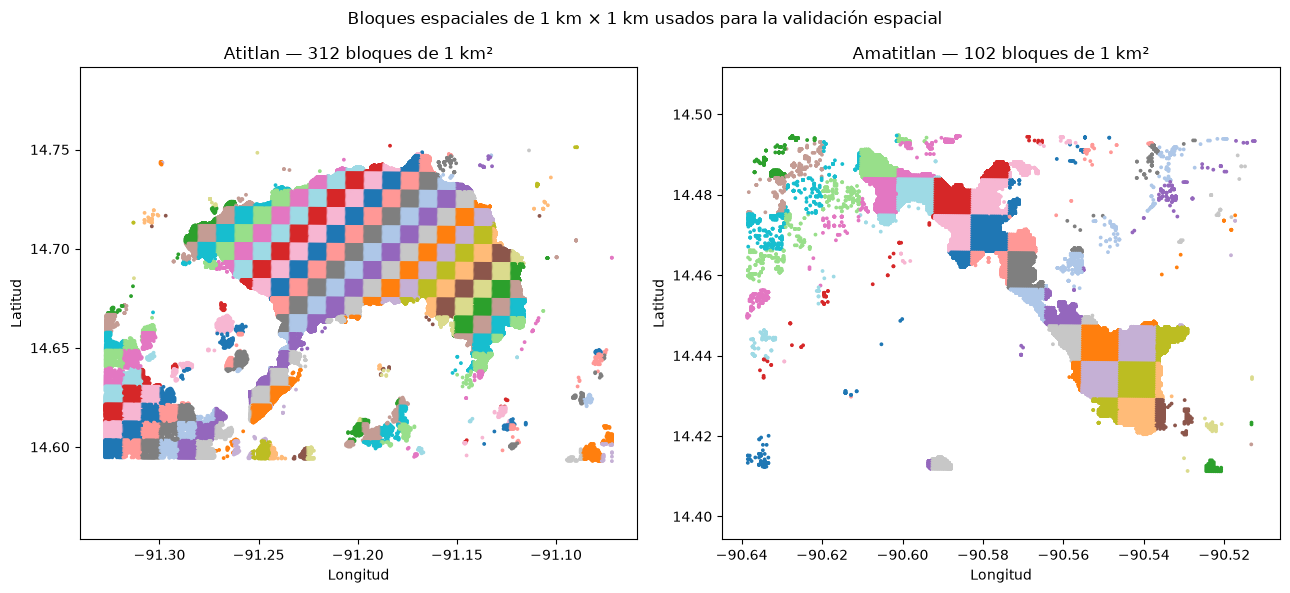

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, lago in zip(axes, ["atitlan", "amatitlan"]):
    sub = df[df["lago"] == lago]
    col = sub["bloque_id"].str.split("_").str[1].astype(int)
    fila = sub["bloque_id"].str.split("_").str[2].astype(int)
    color_idx = (col * 7 + fila * 13) % 20  # dispersa colores vecinos en la paleta
    sc = ax.scatter(sub["lon"], sub["lat"], c=color_idx, cmap="tab20", s=3)
    ax.set_title(f"{lago.capitalize()} — {sub['bloque_id'].nunique()} bloques de 1 km²")
    ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
    ax.set_aspect("equal", adjustable="datalim")
fig.suptitle("Bloques espaciales de 1 km × 1 km usados para la validación espacial")
plt.tight_layout()
plt.show()


## 6.3-6.4 Validación cruzada espacial (GroupKFold por bloque)



In [5]:
preprocesador_lineal = ColumnTransformer([
    ("num", StandardScaler(), NUM_FEATURES),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), CAT_FEATURES),
])
preprocesador_arboles = ColumnTransformer([
    ("num", "passthrough", NUM_FEATURES),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), CAT_FEATURES),
])

n_neg, n_pos = np.bincount(y)
scale_pos_weight = n_neg / n_pos

# Mismos hiperparámetros seleccionados en el Ejercicio 4
modelos_espacial = {
    "Regresión Logística": Pipeline([
        ("pre", preprocesador_lineal),
        ("clf", LogisticRegression(C=1, max_iter=5000, class_weight="balanced",
                                    random_state=RANDOM_STATE)),
    ]),
    "Random Forest": Pipeline([
        ("pre", preprocesador_arboles),
        ("clf", RandomForestClassifier(n_estimators=400, max_depth=20, min_samples_leaf=5,
                                        max_features="sqrt", class_weight="balanced",
                                        random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    "XGBoost": Pipeline([
        ("pre", preprocesador_arboles),
        ("clf", XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.1,
                               subsample=0.9, colsample_bytree=0.9,
                               tree_method="hist", eval_metric="aucpr",
                               scale_pos_weight=scale_pos_weight,
                               random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
}

cv_espacial = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
groups = df["bloque_id"]


In [6]:
proba_espacial = {}
for nombre, pipe in modelos_espacial.items():
    proba = cross_val_predict(
        pipe, X, y, cv=cv_espacial, groups=groups,
        method="predict_proba", n_jobs=1,
    )[:, 1]
    proba_espacial[nombre] = proba
    print(f"{nombre}: listo")


Regresión Logística: listo


Random Forest: listo


XGBoost: listo


In [7]:
def calcular_metricas(y_true, y_proba, umbral=0.5):
    y_pred = (y_proba >= umbral).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label=1),
        "recall": recall_score(y_true, y_pred, pos_label=1),
        "f1": f1_score(y_true, y_pred, pos_label=1),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
    }

metricas_espacial = pd.DataFrame({
    nombre: calcular_metricas(y, proba) for nombre, proba in proba_espacial.items()
}).T
metricas_espacial.index.name = "modelo"
metricas_espacial.round(4)


,accuracy,precision,recall,f1,roc_auc,pr_auc
modelo,,,,,,
Regresión Logística,0.8932,0.4010,0.9116,0.5570,0.9528,0.6893
Random Forest,0.9567,0.6455,0.9128,0.7562,0.9857,0.8800
XGBoost,0.9563,0.6447,0.9070,0.7537,0.9856,0.8968


## 6.5 Comparación con la validación aleatoria (Ejercicio 5)


In [8]:
split_info = pd.read_parquet(OUT_DIR / "split_train_test.parquet").set_index("idx_original")
idx_test = split_info.index[split_info["particion"] == "test"]
X_test, y_test = df.loc[idx_test, FEATURES], df.loc[idx_test, TARGET]

MODELOS_DIR = OUT_DIR / "modelos"
modelos_guardados = {
    "Regresión Logística": joblib.load(MODELOS_DIR / "modelo_logreg.joblib"),
    "Random Forest": joblib.load(MODELOS_DIR / "modelo_rf.joblib"),
    "XGBoost": joblib.load(MODELOS_DIR / "modelo_xgb.joblib"),
}

metricas_aleatoria = pd.DataFrame({
    nombre: calcular_metricas(y_test, modelo.predict_proba(X_test)[:, 1])
    for nombre, modelo in modelos_guardados.items()
}).T
metricas_aleatoria.index.name = "modelo"
metricas_aleatoria.round(4)


,accuracy,precision,recall,f1,roc_auc,pr_auc
modelo,,,,,,
Regresión Logística,0.8943,0.4037,0.9128,0.5598,0.9548,0.6978
Random Forest,0.9602,0.6655,0.9236,0.7736,0.9900,0.9184
XGBoost,0.9614,0.6736,0.9247,0.7794,0.9899,0.9198


In [9]:
comparacion = pd.concat(
    {"Aleatoria (Ej. 5)": metricas_aleatoria, "Espacial (Ej. 6)": metricas_espacial},
    axis=1,
)
comparacion = comparacion.swaplevel(axis=1).sort_index(axis=1, level=0)
diferencia = pd.DataFrame({
    (m, "diferencia (espacial - aleatoria)"): metricas_espacial[m] - metricas_aleatoria[m]
    for m in metricas_aleatoria.columns
})
comparacion.round(4)


accuracy                                 f1  \
                    Aleatoria (Ej. 5) Espacial (Ej. 6) Aleatoria (Ej. 5)   
modelo                                                                     
Regresión Logística            0.8943           0.8932            0.5598   
Random Forest                  0.9602           0.9567            0.7736   
XGBoost                        0.9614           0.9563            0.7794   

                                                pr_auc                   \
                    Espacial (Ej. 6) Aleatoria (Ej. 5) Espacial (Ej. 6)   
modelo                                                                    
Regresión Logística           0.5570            0.6978           0.6893   
Random Forest                 0.7562            0.9184           0.8800   
XGBoost                       0.7537            0.9198           0.8968   

                            precision                             recall  \
                    Aleatoria (Ej. 5) Espacial (Ej. 6) Aleatoria (Ej. 5)   
modelo                                                                     
Regresión Logística            0.4037           0.4010            0.9128   
Random Forest                  0.6655           0.6455            0.9236   
XGBoost                        0.6736           0.6447            0.9247   

                                               roc_auc                   
                    Espacial (Ej. 6) Aleatoria (Ej. 5) Espacial (Ej. 6)  
modelo                                                                   
Regresión Logística           0.9116            0.9548           0.9528  
Random Forest                 0.9128            0.9900           0.9857  
XGBoost                       0.9070            0.9899           0.9856

In [10]:
diferencia_pr_auc = (metricas_espacial["pr_auc"] - metricas_aleatoria["pr_auc"]).rename("Δ PR-AUC")
diferencia_recall = (metricas_espacial["recall"] - metricas_aleatoria["recall"]).rename("Δ Recall")
diferencia_f1 = (metricas_espacial["f1"] - metricas_aleatoria["f1"]).rename("Δ F1")
pd.concat([diferencia_recall, diferencia_f1, diferencia_pr_auc], axis=1).round(4)


,Δ Recall,Δ F1,Δ PR-AUC
modelo,,,
Regresión Logística,-0.0012,-0.0028,-0.0086
Random Forest,-0.0109,-0.0174,-0.0384
XGBoost,-0.0177,-0.0258,-0.0230


## 6.6 Interpretación

El desempeño **disminuyó en los tres modelos** al pasar de validación aleatoria a validación espacial.

| Modelo              | Recall |   F1 | PR-AUC |
| ------------------- | -------: | -----: | -------: |
| Regresión Logística |   -0.001 | -0.003 |   -0.009 |
| Random Forest       |   -0.011 | -0.017 |   -0.038 |
| XGBoost             |   -0.018 | -0.026 |   -0.023 |

La caída fue pequeña en general, pero **Random Forest tuvo la mayor reducción**, especialmente en PR-AUC. Esto ocurre porque en la validación aleatoria pueden quedar puntos muy cercanos tanto en entrenamiento como en prueba, haciendo que el modelo tenga una tarea más fácil y dando resultados un poco optimistas.

La validación espacial es más realista, ya que separa los datos por zonas de 1 km y obliga al modelo a predecir en áreas que no ha visto antes. Esto se parece más a la situación real en la que se utilizaría el modelo para predecir la presencia de cianobacteria en nuevas zonas del lago.

En conclusión, aunque la validación espacial da resultados ligeramente menores, **es la mejor opción para evaluar qué tan bien generalizará el modelo en la práctica**.

